<div style="background-color: #bee7ff; color: white; padding: 30px; border-radius: 0px;">
<h1 style="margin: 0;  color: #1e1a66">Computational Statistics / Gibbs Sampler</h1>
<h3 style="margin: 0;  color: #1e1a66">Samoliuk Oleksandr</h3>
</div>

Imports:

In [109]:
import numpy as np
from scipy.integrate import dblquad

import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import seaborn as sns

---

Metropolis-Hastings needs a proposal density $q$, and for high-dimensional targets, designing a good joint proposal is hard — the algorithm either moves too cautiously in all dimensions at once (poor mixing) or wastes most proposals on rejection. The Gibbs sampler solves this by avoiding the need for a joint proposal distribution altogether. Instead of proposing a move in the whole parameter vector simultaneously, it breaks the multivariate sampling problem into a sequence of much easier univariate (or lower-dimensional) sampling problems:

$$
\text{Multivariate Sampling} \quad \longrightarrow \quad \text{Sequence of Univariate Samplings}
$$

**Algorithm** Gibbs Sampling

* create a Markov chain from a joint distribution
* if random variables $X$, RV $Y$ with joint distribution $f(x,y)$ with conditional densities $f_{X|Y}, f_{Y|X}$
* Markov chain $(X_t, Y_t)$

Algorithm:

* Start with $X_0 = x_0$
* for $t = 1, 2, \dots$ generate
  1. $Y_t \sim f_{Y|X}(\cdot \mid x_{t-1})$
  2. $X_t \sim f_{X|Y}(\cdot \mid y_t)$

Then

* $(X_t, Y_t)$ converges to <span style="color: #db307a;">joint</span> distribution
* both $(X_t)_t$ and $(Y_t)_t$ converge to their <span style="color: #db307a;">marginal distribution</span>

---

In [110]:
np.random.seed(35)

In [111]:
def f(x, y):
    return np.abs(np.exp(-(x**2 + y**2)) * np.sin(4*x*y + 1/2) * np.cos(3*x + y))

def sample_conditional(fixed_val, grid, axis):
    if axis == "y_given_x":
        vals = f(fixed_val, grid)
    else:
        vals = f(grid, fixed_val)

    pdf = vals / np.trapz(vals, grid)
    cdf = np.cumsum(pdf)
    cdf = cdf / cdf[-1]

    cdf_unique, idx = np.unique(cdf, return_index=True)
    grid_unique = grid[idx]

    u = np.random.uniform()
    return np.interp(u, cdf_unique, grid_unique)

def gibbs_sampler(n_iterations, x0=0.0, y0=0.0, grid_range=3.5, grid_points=2000):
    grid = np.linspace(-grid_range, grid_range, grid_points)

    path_x = np.zeros(2 * n_iterations)
    path_y = np.zeros(2 * n_iterations)
    path_x[0], path_y[0] = x0, y0

    x_cur, y_cur = x0, y0
    for t in range(1, n_iterations):
        y_new = sample_conditional(x_cur, grid, axis="y_given_x")
        path_x[2*t - 1], path_y[2*t - 1] = x_cur, y_new

        x_new = sample_conditional(y_new, grid, axis="x_given_y")
        path_x[2*t], path_y[2*t] = x_new, y_new

        x_cur, y_cur = x_new, y_new

    xs = path_x[0::2]
    ys = path_y[0::2]
    return path_x, path_y, xs, ys

In [117]:
a = 2

path_x, path_y, xs, ys = gibbs_sampler(n_iterations=50_000, x0=0.0, y0=0.0, grid_range=a, grid_points=2000)

xg = np.linspace(-a, a, 1000)
Xg, Yg = np.meshgrid(xg, xg)
Zg_raw = f(Xg, Yg)

Z = np.trapz(np.trapz(Zg_raw, xg, axis=1), xg)

def f_normalized(x, y):
    return f(x, y) / Z

Zg = f_normalized(Xg, Yg)

burn = 200
xs_kept, ys_kept = xs[burn:], ys[burn:]

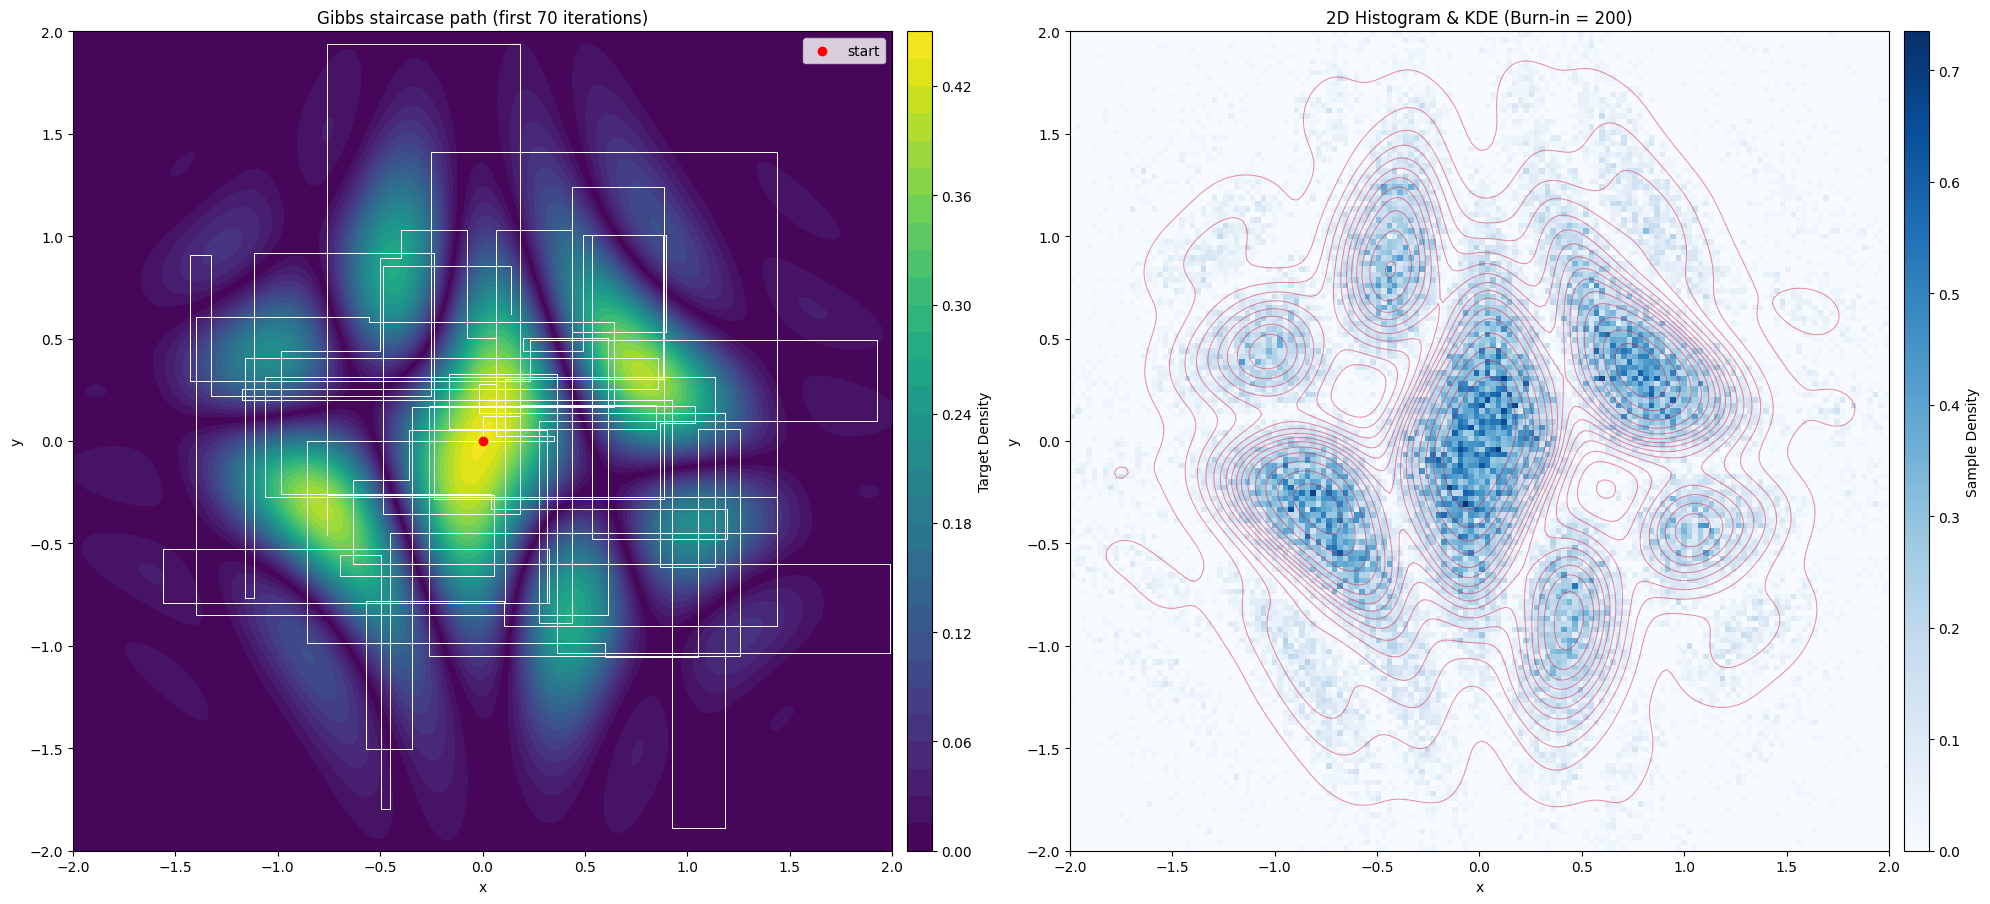

In [128]:
fig, ax = plt.subplots(ncols=2, nrows=1, figsize=(20, 11))

n_show = 70

cf0 = ax[0].contourf(Xg, Yg, Zg, levels=30, cmap="viridis")
ax[0].plot(path_x[:2*n_show], path_y[:2*n_show], color="white", lw=0.7)
ax[0].scatter(path_x[0], path_y[0], color="red", zorder=5, label="start")
ax[0].set_title(f"Gibbs staircase path (first {n_show} iterations)")
ax[0].set_xlabel("x")
ax[0].set_ylabel("y")
ax[0].legend()

counts, xedges, yedges, im = ax[1].hist2d(
    xs_kept, ys_kept, 
    bins=150, 
    cmap="Blues", 
    density=True
)

sns.kdeplot(
    x=xs_kept, 
    y=ys_kept, 
    ax=ax[1], 
    levels=17, 
    color="crimson", 
    linewidths=0.7,
    alpha=0.5
)

ax[1].set_title(f"2D Histogram & KDE (Burn-in = {burn})")
ax[1].set_xlabel("x")
ax[1].set_ylabel("y")

for i in [0, 1]:
    ax[i].set_aspect('equal')
    ax[i].set_xlim([-a, a])
    ax[i].set_ylim([-a, a])

divider1 = make_axes_locatable(ax[1])
cax1 = divider1.append_axes("right", size="3%", pad=0.15)
cbar1 = fig.colorbar(im, cax=cax1)
cbar1.set_label("Sample Density")

divider0 = make_axes_locatable(ax[0])
cax0 = divider0.append_axes("right", size="3%", pad=0.15)
cbar0 = fig.colorbar(cf0, cax=cax0)
cbar0.set_label("Target Density")

plt.tight_layout()
plt.savefig('Outputs/Gibbs_Sampler/Gibbs_2dsamples_Kde_vs_Target.png', bbox_inches='tight')
plt.show()

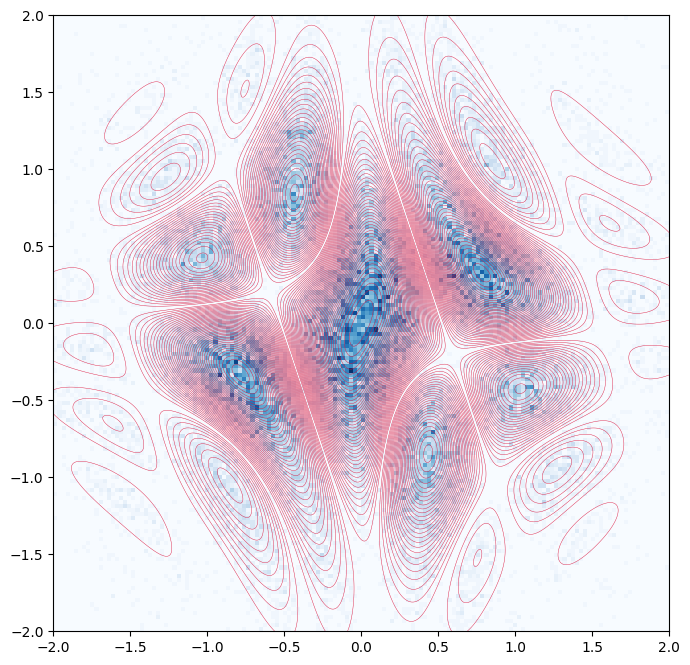

In [122]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.hist2d(xs_kept, ys_kept, bins=150, cmap="Blues", density=True)
ax.contour(Xg, Yg, Zg, levels=50, colors="crimson", linewidths=0.3)
ax.set_xlim([-a, a]); ax.set_ylim([-a, a])
ax.set_aspect("equal")
plt.show()

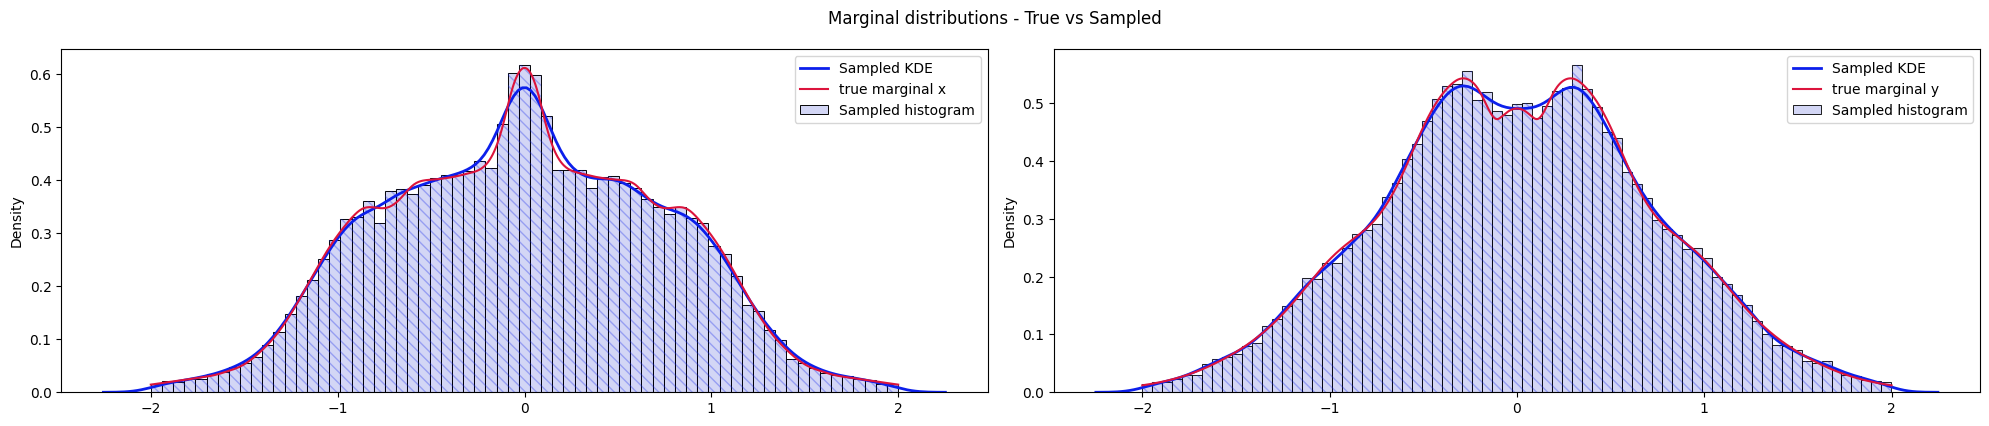

In [153]:
true_marginal_x, true_marginal_y = np.trapz(Zg, xg, axis=0), np.trapz(Zg, xg, axis=1)

fig, ax = plt.subplots(ncols=2, nrows=1, figsize=(20,4.3))

for i, j, k, m in zip([0,1], [true_marginal_x, true_marginal_y], ['x', 'y'], [xs_kept, ys_kept]):

    # ax[i].hist(m, bins=70, density=True, alpha=0.5, label="sampled")
    sns.histplot(
        data=m,
        kde=False,
        stat="density",
        color="#6F79DF",
        edgecolor="#000000",
        alpha=0.3,
        ax=ax[i],
        label="Sampled histogram"
    )  

    sns.histplot(
        data=m,
        kde=False,
        stat="density",
        color="#0C1FEB",
        fill=False,
        edgecolor="#6F79DF",
        hatch='\\\\\\',
        linewidth=0.1,
        alpha=0.3,
        ax=ax[i],
    )

    sns.kdeplot(
        data=m,
        color="#0C1FEB",
        linewidth=2,
        ax=ax[i],
        label="Sampled KDE"
    )

    ax[i].plot(xg, j, color="crimson", label=f"true marginal {k}")
    ax[i].legend()

fig.suptitle('Marginal distributions - True vs Sampled')
fig.tight_layout()

plt.savefig('Outputs/Gibbs_Sampler/Marginal_distributions.png', bbox_inches='tight')
plt.show()

---